Christopher Weiss

Task 1: Data preparation
Subtasks performed in this task are:
-read the 3 into different dataframes
-remove unwanted columns from the report from 2013 to 2019
-add columns year to the the reports of 2020 and 2021
-rename columns to have an uniform name in all reports
-merge all dataframes

In [2]:
import pandas as pd

# importing all csv tables in dataframes
df_report_20= pd.read_csv('report_2020.csv',header=0)
df_report_21= pd.read_csv('report_2021.csv',header=0)
df_report_13_to_19= pd.read_csv('report_2013_to_2019.csv',header=0)

#remove unwanted columns
del df_report_13_to_19["Negative affect"]
del df_report_13_to_19["Positive affect"]

#add years to to the reports of 2020 and 2021
df_report_20["year"]= 2020
df_report_21["year"]= 2021

#rename columns to have an uniform name
df_report_13_to_19= df_report_13_to_19.rename(columns= {
            "Life Ladder": "Ladder score",
            "Log GDP per capita": "Logged GDP per capita",
            "Healthy life expectancy at birth": "Healthy life expectancy"})

#merge all dataframes
df_reports=[df_report_13_to_19,df_report_20,df_report_21]
df_report_13_to_21= pd.concat(df_reports)
df_report_13_to_21= df_report_13_to_21.reset_index(drop=True)

Task 2: Data preparation part 2
-remove any rows without data
-sort by "country name" and "year" in ascending order
-delete all data for countries without full range date

In [3]:
#remove any rows without data
df_report_13_to_21 = df_report_13_to_21.dropna(axis = 0, how ='any') 
df_report_13_to_21= df_report_13_to_21.reset_index(drop=True)


#sort dataframe by "country name" and "year"
df_report_13_to_21 = df_report_13_to_21.sort_values(['Country name','year'])

#delete all countries, which have not the full 16 datasets

#serching for countries, where are not 16 times in the dataframe
number_of_occurrences=df_report_13_to_21['Country name'].value_counts()     
occurrences=number_of_occurrences.to_frame()                        
occurrences=occurrences[occurrences['Country name']!=16]
occurenc_not_16=list(occurrences.index.values)

#deleting all countries, which are less then 16 times in the report
df_report_13_to_21=df_report_13_to_21.set_index("Country name")
df_report_13_to_21= df_report_13_to_21.drop(occurenc_not_16)

Task 3:
-saving Data to a csv file
-calculating happines score for each country
-plotting the 5 happiest and least happiest countries as a bar plot

<AxesSubplot:title={'center':'5 least happiest countries'}>

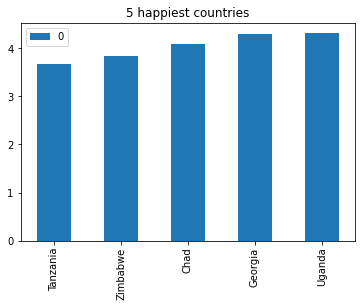

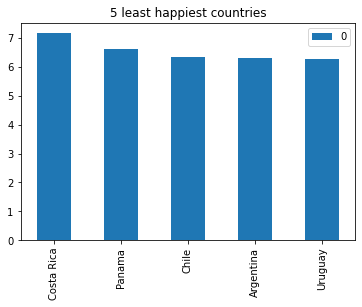

In [34]:
#saving Data to a csv file
df_report_13_to_21.to_csv('report_2013_to_2021.csv')

#calculating happiness score for each country
dict_happiness_unsorted={"initial":1}
dict_happiness_unsorted.pop("initial")
occurrences=number_of_occurrences.to_frame()                        
occurrences=occurrences[occurrences['Country name']==16]
occurenc_16=list(occurrences.index.values)
for x in occurenc_16:
    dict_happiness_unsorted[x]= df_report_13_to_21['Ladder score'].loc[x].mean()

#plot 5 happiest and least happiest countries

#saving the 5 happiest countries
dict_happiness=sorted(dict_happiness_unsorted.items(), key=lambda item: item[1]) #sorting the dict by values
number_of_items=0
dict_5_happiest={"initial":1}
dict_5_happiest.pop("initial")
for x,y in dict_happiness:
    dict_5_happiest[x]=y
    number_of_items=number_of_items+1
    if(number_of_items)==5:
        break

#saving the 5 least happiest countries
dict_happiness=sorted(dict_happiness_unsorted.items(), key=lambda item: item[1],reverse=True)
number_of_items=0
dict_5_least_happiest={"initial":1}
dict_5_least_happiest.pop("initial")
for x,y in dict_happiness:
    dict_5_least_happiest[x]=y
    number_of_items=1+number_of_items
    if(number_of_items)==5:
        break

#generating plots
df_5_happiest_countries=pd.DataFrame.from_dict(dict_5_happiest,orient='index')
df_5_least_happiest_countries=pd.DataFrame.from_dict(dict_5_least_happiest,orient='index')

df_5_happiest_countries.plot(kind='bar',title='5 happiest countries')

df_5_least_happiest_countries.plot(kind='bar',title='5 least happiest countries')



